In [28]:
# Convergence plotter
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from scipy.optimize import curve_fit
import pandas as pd
import matplotlib.patches as patches
import matplotlib.colors as colors

savedir = '/home/kale-chen/Documents/PET/Sensitivity Normalization/writeup/plots/convergence'

# Geometric factors
mapdf = pd.read_csv('/home/kale-chen/Documents/PET/TPPT_Scanner_map_adjusted.csv', header = None)
map = mapdf.to_numpy()[:, 0:3]

# Heatmap utils
heatmapmin, heatmapmax = 0.75, 1.25
def setheatmapminmax(min, max):
    global heatmapmin, heatmapmax
    heatmapmin, heatmapmax = min, max
mapL = mapdf.iloc[3072:]
mapR = mapdf.iloc[:3072]
mapL = np.round(mapL, 2)
mapR = np.round(mapR, 2)
ycoordsL, countsL = np.unique(mapL.iloc[:, 1], return_counts=True)
zcoordsL, countsL = np.unique(mapL.iloc[:, 2], return_counts=True)
ycoordsR, countsR = np.unique(mapR.iloc[:, 1], return_counts=True)
ycoordsR = ycoordsR[::-1] # To keep view from isocenter outwards
zcoordsR, countsR = np.unique(mapR.iloc[:, 2], return_counts=True)
scanner_arc_L = np.zeros((32, 96))
scanner_arc_R = np.zeros((32, 96))
for i in range(3072):
    scanner_arc_R[np.where(zcoordsR == mapR.iloc[i, 2]), np.where(ycoordsR == mapR.iloc[i, 1])] = i
for i in range(3072):
    scanner_arc_L[np.where(zcoordsL == mapL.iloc[i, 2]), np.where(ycoordsL == mapL.iloc[i, 1])] = i+3072
def getcolor(value, cmap = 'RdBu_r', numdiscretecolors = 20):
        colormap = plt.get_cmap(cmap)
        if value < heatmapmin:
            return colormap(0.0)
        elif value > heatmapmax:
            return colormap(1.0)
        else:
            return colormap((value - heatmapmin) / (heatmapmax - heatmapmin) * (numdiscretecolors - 2) // 1 / (numdiscretecolors - 2))
def makeheatmap(countsIDorder,title, savename, heatmapmin = 0.75, heatmapmax = 1.25):
    setheatmapminmax(heatmapmin, heatmapmax)
    heatmapL = np.zeros((32, 96))
    heatmapR = np.zeros((32, 96))
    for i in range(3072):
        index = np.where(scanner_arc_R == i)
        heatmapR[index] = countsIDorder[i]
    for i in range(3072, 6144):
        index = np.where(scanner_arc_L == i)
        heatmapL[index] = countsIDorder[i]
    heatmapR = heatmapR / np.median(heatmapR)
    heatmapL = heatmapL / np.median(heatmapL)
    #Dead cells
    for i in range(32):
        for j in range(96):
            if heatmapR[i, j] == 0:
                heatmapR[i, j] = -1
            if heatmapL[i, j] == 0:
                heatmapL[i, j] = -1

    face_dim = 3.2
    space = 1.2
    blank_color = 'black'
    cmap = plt.get_cmap('RdBu_r') # 'seismic' or 'RdBu' or 'rwb'
        
    fig, ax = plt.subplots(figsize = (8, 6))

    #rect = patches.Rectangle((-2, -104.8), 324.4, 225.6, facecolor='black', alpha = 0.2)
    #ax.add_patch(rect)

    # Plot R
    for z in range(32):
        zspace = z // 8 * space
        for y in range(96):
            yspace = y // 8 * space
            if heatmapR[z, y] != -1:
                rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace)), face_dim, face_dim, facecolor=getcolor(heatmapR[z, y], cmap = cmap))
                ax = plt.gca()
                ax.add_patch(rect)
            else:
                rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace)), face_dim, face_dim, facecolor=blank_color)
                ax = plt.gca()
                ax.add_patch(rect)

    # Plot L
    for z in range(32):
        zspace = z // 8 * space 
        for y in range(96):
            yspace = y // 8 * space
            if heatmapL[z, y] != -1:
                rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace)+ 110), face_dim, face_dim, facecolor=getcolor(heatmapL[z, y], cmap = cmap))
                ax = plt.gca()
                ax.add_patch(rect)
            else:
                rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace) + 110), face_dim, face_dim, facecolor=blank_color)
                ax = plt.gca()
                ax.add_patch(rect)
    bounds = np.linspace(heatmapmin, heatmapmax, 21)
    norm = colors.BoundaryNorm(bounds, cmap.N)
    mappable = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = plt.colorbar(mappable, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
    diff = heatmapmax - heatmapmin
    cbar.set_ticks([heatmapmin, heatmapmin+diff*0.0, heatmapmin+diff*0.1, heatmapmin+diff*0.15, heatmapmin+diff*0.2, heatmapmin+diff*0.25, heatmapmin+diff*0.3, heatmapmin+diff*0.35, heatmapmin+diff*0.4, heatmapmin+diff*0.45, heatmapmin+diff*0.5, heatmapmin+diff*0.55, heatmapmin+diff*0.6, heatmapmin+diff*0.65, heatmapmin+diff*0.7, heatmapmin+diff*0.75, heatmapmin+diff*0.8, heatmapmin+diff*0.85, heatmapmin+diff*0.9, heatmapmin+diff*0.95, heatmapmax])
    cbar.set_ticklabels([
        '',
        #f'{heatmapmin:.2e}',
        f'{heatmapmin}',
        '', '', '', '', '', '', '', '',
        f'{heatmapmin+diff*0.5}',
        '', '', '', '', '', '', '', '', '',
        f'{heatmapmax}'
    ])
    plt.xlim(-2,322.4)
    pady = 36
    plt.ylim(-104.8 - pady, 113.2)
    plt.axis('off')
    #plt.tight_layout()
    plt.title(title)
    plt.savefig(os.path.join(savedir, f'{savename}heatmap.pdf'), format='pdf', dpi=300, bbox_inches='tight')
    plt.show()

def makehist(eventcounts, eventcountsIDorder, title, savename, fit = True, heatmapmin = 0.75, heatmapmax = 1.25):
    plt.figure(1, figsize = (6, 3))
    bins = np.linspace(heatmapmin, heatmapmax, 200)
    plt.hist(eventcounts / np.median(eventcounts), bins = bins, color = 'red', label = 'Unnormalized', histtype = 'step', linewidth = 1)
    hist, bins = plt.hist(eventcountsIDorder / np.median(eventcountsIDorder), bins = bins, color = 'blue', label = 'Normalized', histtype = 'step', linewidth = 1)[0:2]
    def gaussian(x, a, mu, sigma):
        return a * np.exp(-(x - mu)**2 / (2 * sigma**2))
    if fit:
        bincenters = (bins[1:] + bins[:-1]) / 2
        popt, _ = curve_fit(gaussian, bincenters, hist, p0 = [100, 1.0, 0.03])
        print(popt)
        plotting_bounds = np.linspace(popt[1] - 4 * popt[2], popt[1] + 4 * popt[2], 100)
        plt.plot(plotting_bounds, gaussian(plotting_bounds, *popt), color = 'black', label = f'sigma = {np.abs(popt[2]):.4f}')
    plt.legend()
    plt.xlim(heatmapmin - 0.02, heatmapmax + 0.02)
    plt.xlabel('Channel activity scaled to median')
    plt.ylabel('Num channels')
    plt.title(title)
    plt.savefig(os.path.join(savedir, f'{savename}hist.pdf'), format='pdf', dpi=300, bbox_inches='tight')
    plt.show()


Event counts: 100%|██████████| 20/20 [00:00<00:00, 20.62it/s]


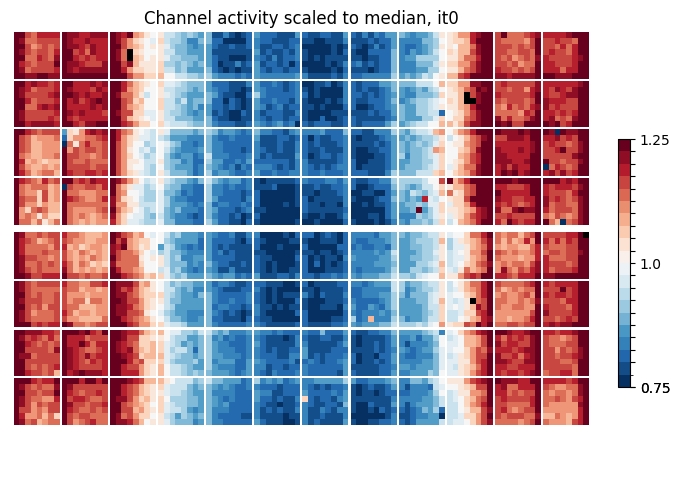

Event counts: 100%|██████████| 20/20 [00:00<00:00, 37.74it/s]


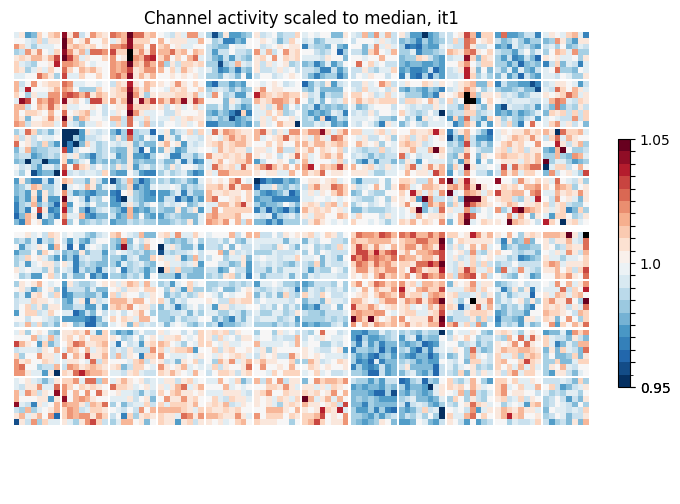

[ 3.83253318e+02  9.99817868e-01 -1.60384469e-02]


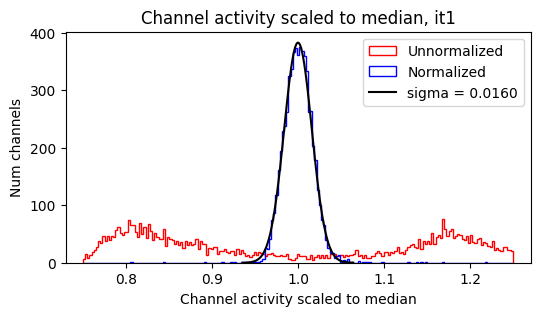

Event counts: 100%|██████████| 20/20 [00:00<00:00, 39.16it/s]


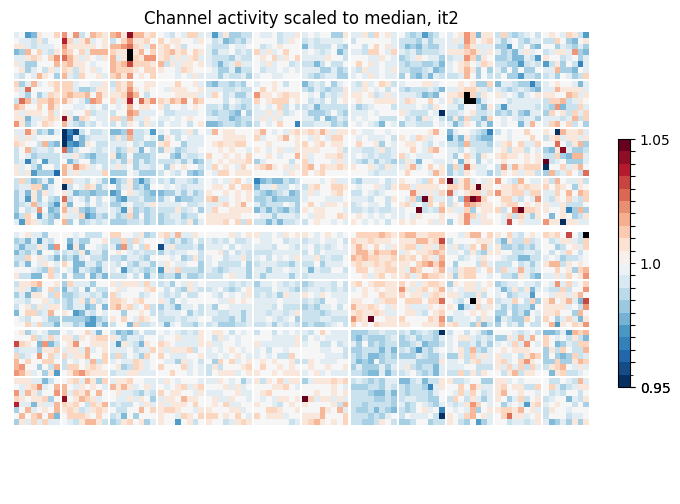

[6.39703530e+02 9.99763498e-01 9.52933381e-03]


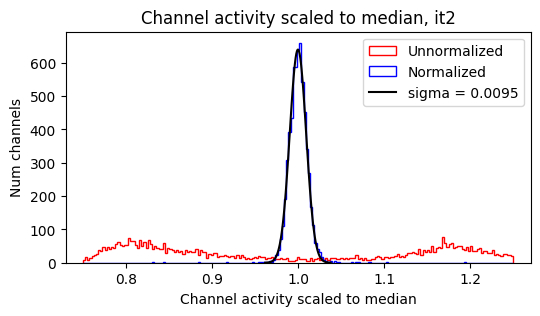

Event counts: 100%|██████████| 20/20 [00:00<00:00, 34.85it/s]


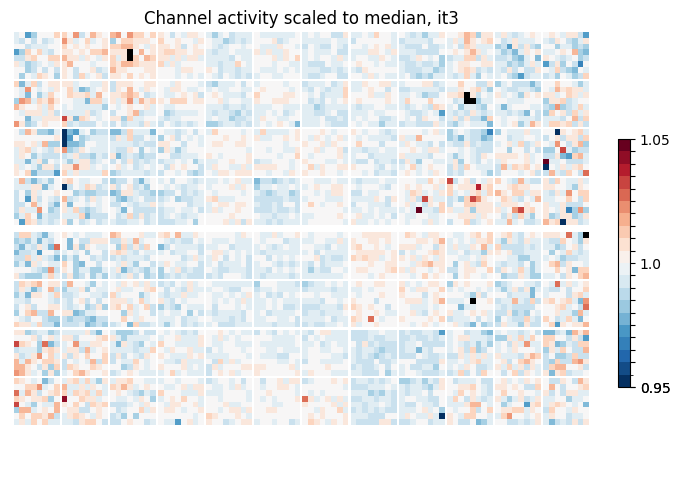

[8.94410739e+02 9.99888142e-01 6.65056901e-03]


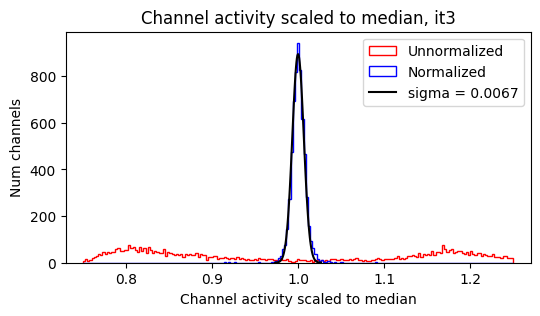

Event counts: 100%|██████████| 20/20 [00:00<00:00, 37.69it/s]


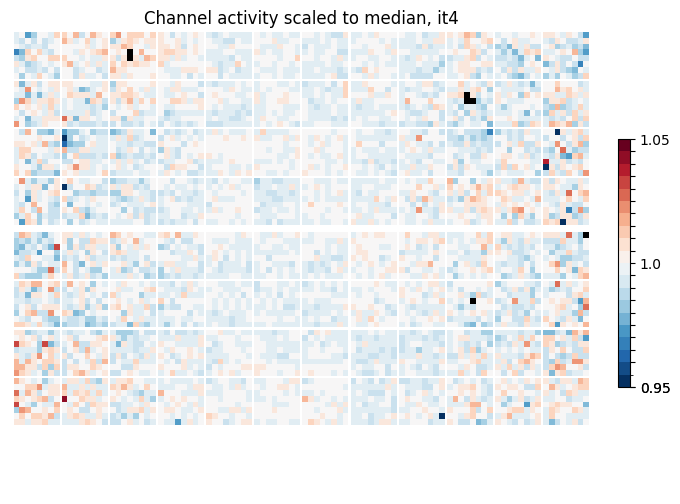

[1.04207437e+03 9.99883654e-01 5.55720114e-03]


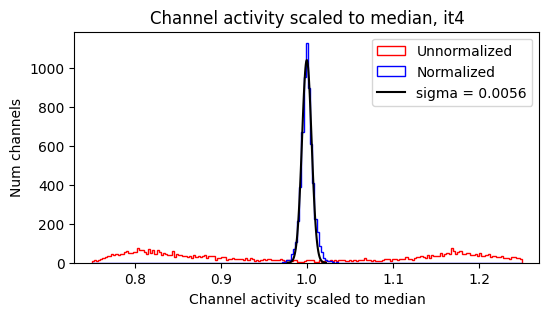

Event counts: 100%|██████████| 20/20 [00:00<00:00, 34.12it/s]


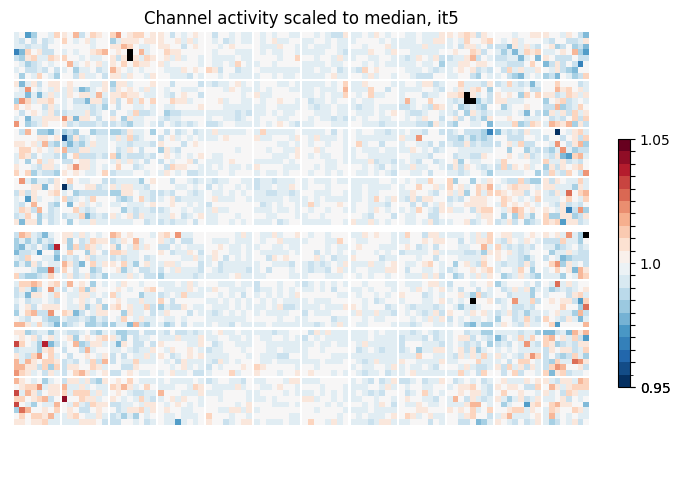

[1.10713042e+03 9.99850161e-01 5.15721508e-03]


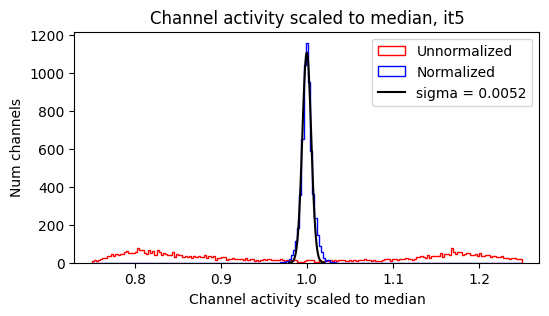

Event counts: 100%|██████████| 20/20 [00:00<00:00, 35.88it/s]


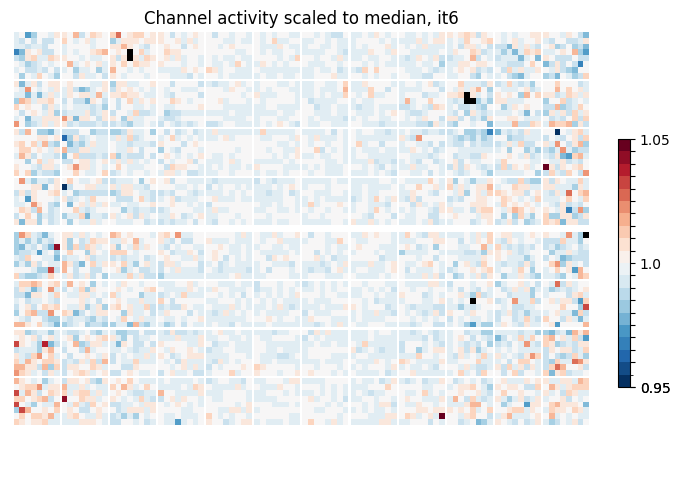

[1.13066935e+03 9.99868244e-01 5.01252025e-03]


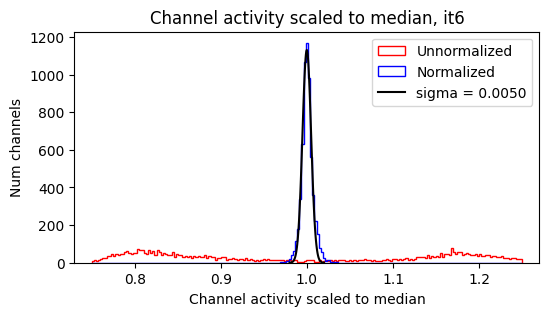

Event counts: 100%|██████████| 20/20 [00:00<00:00, 36.72it/s]


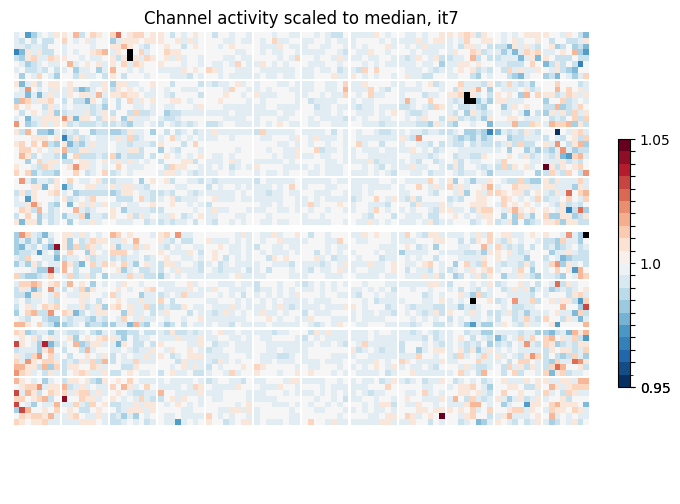

[1.13131324e+03 9.99855394e-01 5.00934040e-03]


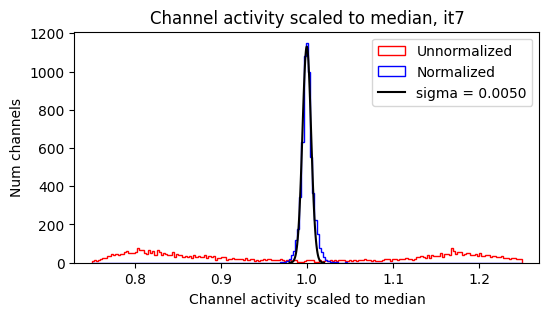

Event counts: 100%|██████████| 20/20 [00:00<00:00, 35.72it/s]


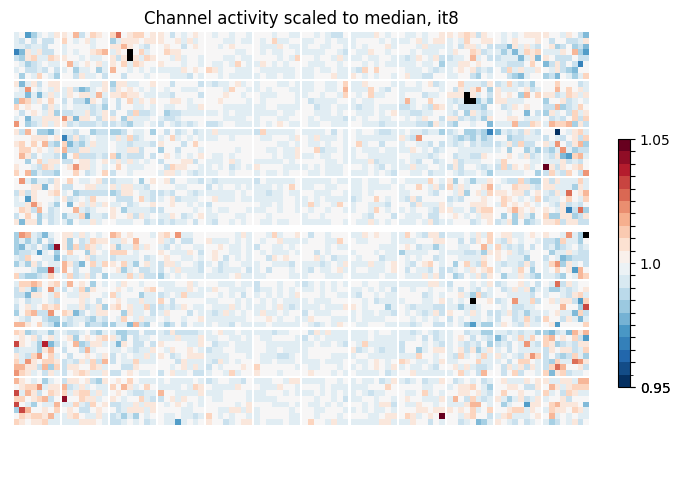

[1.13112166e+03 9.99852982e-01 5.00738820e-03]


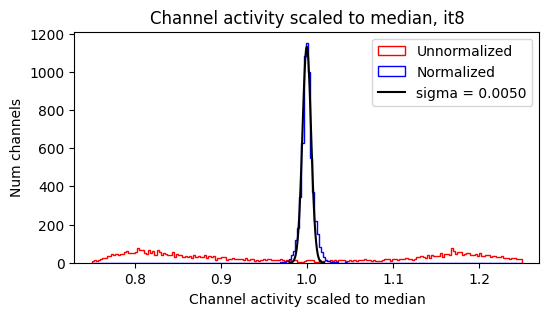

Event counts: 100%|██████████| 20/20 [00:00<00:00, 33.35it/s]


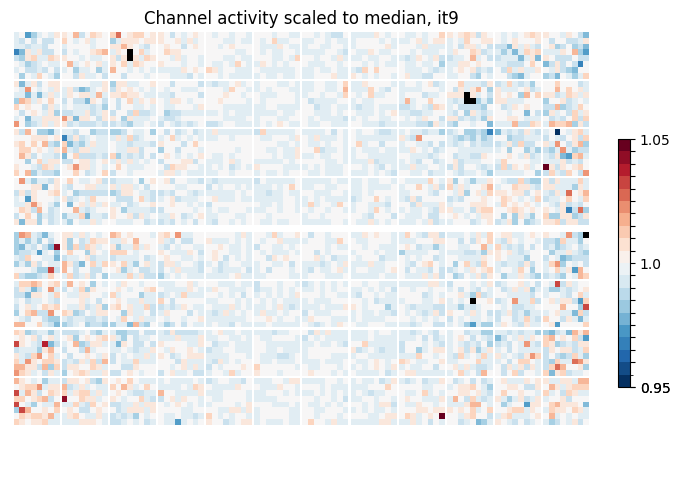

[1.13384583e+03 9.99844163e-01 4.98894168e-03]


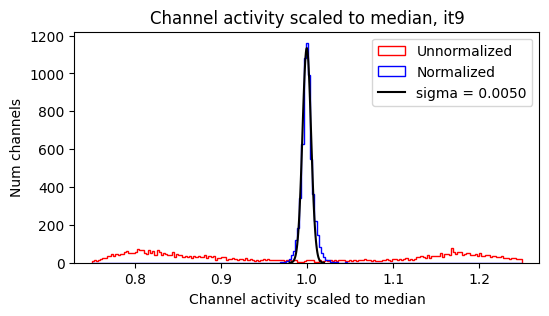

Event counts: 100%|██████████| 20/20 [00:00<00:00, 38.34it/s]


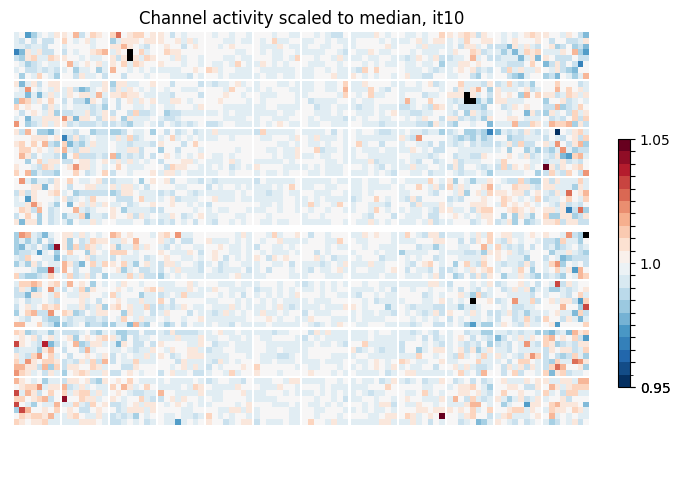

[1.13276397e+03 9.99854958e-01 4.99575231e-03]


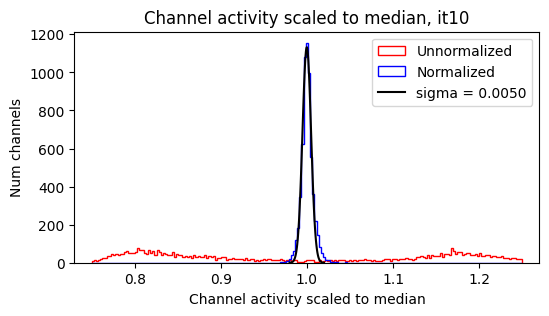

In [ ]:
# Apply normalization per LOR
name = 'hcircpgd'
path = f'/home/kale-chen/Documents/PET/TPPT2026/data/{name}.bin'
num_cols, data_size = 4, 2
num_rows = os.path.getsize(path) // (num_cols * data_size)
data = np.memmap(path, dtype = np.int16, mode = 'r', shape = (num_rows, num_cols))
geomsensitivity = np.fromfile('geomsensitivity.bin', dtype = np.float32).reshape(3072, 3072)
acceptancetable = np.fromfile('acceptancetable.bin', dtype = np.bool).reshape(3072, 3072)

eventcounts0 = np.zeros((3072, 3072), dtype = np.float32)
for i in tqdm(range(0, num_rows, 1000000), desc='Event counts'):
    chunk = data[i:i+1000000]
    if num_cols == 3:
        idls = np.asarray(chunk[:, 0], dtype = np.int32)
        idrs = np.asarray(chunk[:, 1], dtype = np.int32)
    elif num_cols == 6:
        idls = np.asarray(chunk[:, 1], dtype = np.int32)
        idrs = np.asarray(chunk[:, 3], dtype = np.int32)
    elif num_cols == 4:
        idls = np.asarray(chunk[:, 0], dtype = np.int32)
        idrs = np.asarray(chunk[:, 1], dtype = np.int32)
    np.add.at(eventcounts0, (idls, idrs), 1 / geomsensitivity[idls, idrs])
eventcountsIDorder0 = np.concatenate((eventcounts0.sum(axis = 0), eventcounts0.sum(axis = 1)), axis = 0)
makeheatmap(eventcountsIDorder0, 'Channel activity scaled to median, it0', 'it0heatmap')
iterations = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
for it in iterations:
    normfactorsL = np.fromfile(f'normfactors/it{it-1}L.bin', dtype = np.float32)
    normfactorsR = np.fromfile(f'normfactors/it{it-1}R.bin', dtype = np.float32)
    eventcounts = np.zeros((3072, 3072), dtype = np.float32)
    for i in tqdm(range(0, num_rows, 1000000), desc='Event counts'):
        chunk = data[i:i+1000000]
        if num_cols == 3:
            idls = np.asarray(chunk[:, 0], dtype = np.int32)
            idrs = np.asarray(chunk[:, 1], dtype = np.int32)
        elif num_cols == 6:
            idls = np.asarray(chunk[:, 1], dtype = np.int32)
            idrs = np.asarray(chunk[:, 3], dtype = np.int32)
        elif num_cols == 4:
            idls = np.asarray(chunk[:, 0], dtype = np.int32)
            idrs = np.asarray(chunk[:, 1], dtype = np.int32)
        np.add.at(eventcounts, (idls, idrs), 1 / geomsensitivity[idls, idrs] / normfactorsL[idls] / normfactorsR[idrs])
    eventcountsIDorder = np.concatenate((eventcounts.sum(axis = 0), eventcounts.sum(axis = 1)), axis = 0)
    makeheatmap(eventcountsIDorder, f'Channel activity scaled to median, it{it}', f'it{it}heatmap', heatmapmin = 0.95, heatmapmax = 1.05)
    makehist(eventcountsIDorder0, eventcountsIDorder, f'Channel activity scaled to median, it{it}', f'it{it}hist', heatmapmin = 0.75, heatmapmax = 1.25)

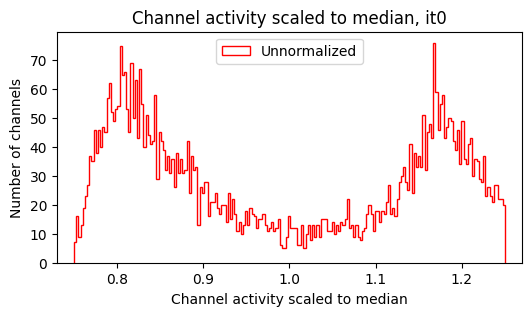

In [30]:
plt.figure(1, figsize = (6, 3))
bins = np.linspace(0.75, 1.25, 200)
plt.hist(eventcountsIDorder0 / np.median(eventcountsIDorder0), bins = bins, color = 'red', label = 'Unnormalized', histtype = 'step', linewidth = 1)
plt.legend()
plt.xlim(0.75 - 0.02, 1.25 + 0.02)
plt.xlabel('Channel activity scaled to median')
plt.ylabel('Number of channels')
plt.title('Channel activity scaled to median, it0')
plt.savefig(os.path.join(savedir, f'it0hist.pdf'), format='pdf', dpi=300, bbox_inches='tight')
plt.show()